In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.initializers import GlorotUniform
import tensorflow as tf
import keras_tuner as kt
import math, os, random, joblib

# =============================================================================
# CONSTANTS
# =============================================================================
EPS      = 1e-10
DEPTH    = 'depth_m'
RES      = 'mt_res_ohmm'
PHI      = 'ndphi_mean'
PHI_PRED = 'ndphi_mean_pred'
ERR_COL  = 'Error_Relatif_Persen'
TYPE_COL = 'Data_Type'

# =============================================================================
# REPRODUCIBILITY
# =============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    print("Warning: deterministic ops not available on this device.")

# =============================================================================
# KERAS TUNER CONFIG
# =============================================================================
TUNER_DIR      = 'keras_tuner_results_dense'
TUNER_PROJECT  = 'dense_porosity'
MAX_TRIALS     = 200
TUNER_EPOCHS   = 50
TUNER_PATIENCE = 15
FINAL_EPOCHS   = 200
FINAL_PATIENCE = 20

# =============================================================================
# FILE PATHS
# =============================================================================
model_filename = 'model_B_dense_tuned.keras'
scaler_X_path  = 'scaler_X_B_dense_tuned.pkl'
scaler_y_path  = 'scaler_Y_B_dense_tuned.pkl'
best_hp_path   = 'best_hp_dense.pkl'
force_retrain  = True

# =============================================================================
# 1) LOAD & SORT DATA
# =============================================================================
try:
    data = pd.read_csv("resampled_1m_78B_AT90(ohm.m)_78.csv", sep=';')
except FileNotFoundError:
    print("Error: File CSV tidak ditemukan!")
    exit()

print(f"Data berhasil dimuat: {len(data)} baris")

data_sorted = data.sort_values(DEPTH, ascending=False).reset_index(drop=True)
min_z   = data_sorted[DEPTH].min()
max_z   = data_sorted[DEPTH].max()
z_range = max_z - min_z

train_percentage      = 0.85
validation_percentage = 0.05
test_percentage       = 0.10

test_limit     = min_z + z_range * test_percentage
test_mask      = data_sorted[DEPTH] <= test_limit
train_val_mask = ~test_mask

test_data      = data_sorted[test_mask]
train_val_data = data_sorted[train_val_mask]

train_val_range = train_val_data[DEPTH].max() - train_val_data[DEPTH].min()
train_limit     = train_val_data[DEPTH].max() - train_val_range * (
    train_percentage / (1 - test_percentage))

train_data      = train_val_data[train_val_data[DEPTH] > train_limit]
validation_data = train_val_data[train_val_data[DEPTH] <= train_limit]

print(f"Range keseluruhan : {max_z:.2f}m – {min_z:.2f}m")
print(f"Training range    : {train_data[DEPTH].max():.2f}m – {train_data[DEPTH].min():.2f}m  ({len(train_data)} pts, {len(train_data)/len(data_sorted)*100:.1f}%)")
print(f"Validation range  : {validation_data[DEPTH].max():.2f}m – {validation_data[DEPTH].min():.2f}m  ({len(validation_data)} pts, {len(validation_data)/len(data_sorted)*100:.1f}%)")
print(f"Testing range     : {test_data[DEPTH].max():.2f}m – {test_data[DEPTH].min():.2f}m  ({len(test_data)} pts, {len(test_data)/len(data_sorted)*100:.1f}%)")

# =============================================================================
# 2) RAW FEATURE ARRAYS
# =============================================================================
X_train_raw = train_data[[RES, DEPTH]].values
y_train_raw = train_data[[PHI]].values
X_val_raw   = validation_data[[RES, DEPTH]].values
y_val_raw   = validation_data[[PHI]].values
X_test_raw  = test_data[[RES, DEPTH]].values
y_test_raw  = test_data[[PHI]].values

# =============================================================================
# 3) SCALERS (fit on train only)
# =============================================================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train_raw)
y_train_sc = scaler_y.fit_transform(y_train_raw)
X_val_sc   = scaler_X.transform(X_val_raw)
y_val_sc   = scaler_y.transform(y_val_raw)
X_test_sc  = scaler_X.transform(X_test_raw)
y_test_sc  = scaler_y.transform(y_test_raw)

# =============================================================================
# 4) LABEL DATA TYPE
# =============================================================================
def assign_data_type(z):
    if z <= test_limit:
        return 'Testing'
    elif z <= train_limit:
        return 'Validation'
    else:
        return 'Training'

data_sorted[TYPE_COL] = data_sorted[DEPTH].apply(assign_data_type)

# =============================================================================
# 5) MODEL BUILDER — tuning jumlah Dense+LeakyReLU layer {1, 2, 3}
# =============================================================================
def build_model(hp):
    num_layers  = hp.Int   ('num_layers',   min_value=1, max_value=3, step=1)
    leaky_alpha = hp.Choice('leaky_alpha',  values=[0.01, 0.1, 0.2, 0.3])
    lr          = hp.Choice('learning_rate',values=[1e-3, 5e-4, 1e-4, 5e-5, 1e-5])
    hp.Choice('batch_size', values=[4, 8, 16, 32])

    model = Sequential()

    # ── DENSE + LEAKYRELU LAYERS ─────────────────────────────────
    for i in range(num_layers):
        units        = hp.Choice(f'units_{i}',   values=[16, 32, 64, 128])
        dropout_rate = hp.Float (f'dropout_{i}',
                                  min_value=0.0, max_value=0.4, step=0.1)

        if i == 0:
            model.add(Dense(
                units,
                input_dim=2,
                kernel_initializer=GlorotUniform(seed=SEED),
                name=f'dense_{i+1}'
            ))
        else:
            model.add(Dense(
                units,
                kernel_initializer=GlorotUniform(seed=SEED),
                name=f'dense_{i+1}'
            ))

        model.add(LeakyReLU(alpha=leaky_alpha, name=f'leaky_{i+1}'))
        model.add(Dropout(dropout_rate, seed=SEED, name=f'drop_{i+1}'))

    # ── OUTPUT LAYER ─────────────────────────────────────────────
    model.add(Dense(
        1,
        activation='linear',
        kernel_initializer=GlorotUniform(seed=SEED),
        name='output'
    ))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=MeanSquaredError(),
        metrics=['mae'],
    )
    return model

# =============================================================================
# 6) CUSTOM TUNER
# =============================================================================
class DenseTuner(kt.BayesianOptimization):

    def run_trial(self, trial, epochs=TUNER_EPOCHS, callbacks=None, **kwargs):
        hp         = trial.hyperparameters
        batch_size = hp.get('batch_size') if 'batch_size' in hp.values else 8

        model = self.hypermodel.build(hp)

        history = model.fit(
            X_train_sc, y_train_sc,
            validation_data=(X_val_sc, y_val_sc),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks or [],
            verbose=0,
        )

        # Penalize collapsed predictions
        val_preds = model.predict(X_val_sc, verbose=0).flatten()
        pred_std  = np.std(val_preds)
        true_std  = np.std(y_val_sc.flatten())
        std_ratio = pred_std / (true_std + 1e-8)
        penalty   = 0.05 * np.exp(-std_ratio)

        base_loss = min(history.history['val_loss'])
        score     = base_loss + penalty

        self.oracle.update_trial(trial.trial_id, {'val_loss': score})
        return history

# =============================================================================
# 7) RUN TUNER OR LOAD EXISTING MODEL
# =============================================================================
model_ready = (
    os.path.exists(model_filename) and
    os.path.exists(scaler_X_path)  and
    os.path.exists(scaler_y_path)  and
    os.path.exists(best_hp_path)   and
    not force_retrain
)

if model_ready:
    print("\nMemuat model & scaler yang sudah ada …")
    try:
        model    = load_model(model_filename)
        scaler_X = joblib.load(scaler_X_path)
        scaler_y = joblib.load(scaler_y_path)
        best_hp  = joblib.load(best_hp_path)
        print(f"Model dimuat. Jumlah layer terbaik : {best_hp.get('num_layers')}")
    except Exception as e:
        print(f"Gagal memuat: {e}\nMelatih ulang …")
        force_retrain = True

if force_retrain:
    tuner = DenseTuner(
        hypermodel           = build_model,
        objective            = kt.Objective('val_loss', direction='min'),
        max_trials           = MAX_TRIALS,
        executions_per_trial = 1,
        seed                 = SEED,
        directory            = TUNER_DIR,
        project_name         = TUNER_PROJECT,
        overwrite            = True,
    )

    tuner.search_space_summary()

    search_callbacks = [
        EarlyStopping(monitor='val_loss', patience=TUNER_PATIENCE,
                      restore_best_weights=True),
    ]

    print("\n" + "="*60)
    print("  MULAI KERAS TUNER SEARCH (Dense + LeakyReLU) …")
    print(f"  Max trials : {MAX_TRIALS}  |  Epochs/trial : {TUNER_EPOCHS}")
    print("="*60 + "\n")

    tuner.search(
        epochs    = TUNER_EPOCHS,
        callbacks = search_callbacks,
    )

    best_hp_obj    = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_hp        = best_hp_obj.values
    best_batch     = best_hp.get('batch_size', 8)
    best_num_layers = best_hp.get('num_layers', 2)

    print("\n" + "="*60)
    print("  HYPERPARAMETER TERBAIK:")
    for k, v in best_hp.items():
        print(f"    {k:<25} = {v}")
    print("="*60 + "\n")

    model = tuner.hypermodel.build(best_hp_obj)
    model.summary()

    final_callbacks = [
        EarlyStopping(monitor='val_loss', patience=FINAL_PATIENCE,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=5, min_lr=1e-6),
    ]

    print("\nMelatih model final dengan HP terbaik …")
    history = model.fit(
        X_train_sc, y_train_sc,
        validation_data=(X_val_sc, y_val_sc),
        epochs=FINAL_EPOCHS,
        batch_size=best_batch,
        callbacks=final_callbacks,
        verbose=1,
    )

    try:
        model.save(model_filename)
        joblib.dump(scaler_X, scaler_X_path)
        joblib.dump(scaler_y, scaler_y_path)
        joblib.dump(best_hp,  best_hp_path)
        print(f"\nModel disimpan → {model_filename}")
    except Exception as e:
        print(f"Warning: tidak bisa menyimpan: {e}")

# =============================================================================
# 8) EVALUASI
# =============================================================================
def predict_inverse(X_raw):
    return scaler_y.inverse_transform(
        model.predict(scaler_X.transform(X_raw), verbose=0)
    )

y_pred_train = predict_inverse(X_train_raw)
y_pred_val   = predict_inverse(X_val_raw)
y_pred_test  = predict_inverse(X_test_raw)

def eval_metrics(y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPS))) * 100
    return rmse, r2, mape

rmse_train, r2_train, mape_train = eval_metrics(y_train_raw, y_pred_train)
rmse_val,   r2_val,   mape_val   = eval_metrics(y_val_raw,   y_pred_val)
rmse_test,  r2_test,  mape_test  = eval_metrics(y_test_raw,  y_pred_test)

all_X_sc  = scaler_X.transform(data_sorted[[RES, DEPTH]].values)
all_y_pred = scaler_y.inverse_transform(
    model.predict(all_X_sc, verbose=0)).flatten()
y_true_all = data_sorted[PHI].values

rmse_overall, r2_overall, mape_overall = eval_metrics(y_true_all, all_y_pred)
rrmse_overall = np.sqrt(np.sum((y_true_all - all_y_pred)**2) /
                        (np.sum(y_true_all**2) + EPS)) * 100

data_sorted[PHI_PRED] = all_y_pred
data_sorted[ERR_COL]  = (
    np.abs(y_true_all - all_y_pred) /
    (np.abs(y_true_all) + EPS)
) * 100

train_sc     = data_sorted[data_sorted[TYPE_COL] == 'Training'].copy()
val_sc       = data_sorted[data_sorted[TYPE_COL] == 'Validation'].copy()
test_sc      = data_sorted[data_sorted[TYPE_COL] == 'Testing'].copy()
train_depths = train_sc[DEPTH]
val_depths   = val_sc[DEPTH]
test_depths  = test_sc[DEPTH]

# =============================================================================
# 9) PRINT HASIL
# =============================================================================
W = 80
print("\n" + "=" * W)
print(f"  EVALUASI MODEL DENSE + LEAKYRELU + KERAS TUNER")
print(f"  Best HP : num_layers={best_hp.get('num_layers')}"
      f"  leaky_alpha={best_hp.get('leaky_alpha')}"
      f"  lr={best_hp.get('learning_rate'):.0e}"
      f"  batch={best_hp.get('batch_size')}")
print("=" * W)
print(f"  {'Metrik':<22} {'Training':>12} {'Validation':>12} {'TEST':>12} {'Overall':>12}")
print("-" * W)
print(f"  {'RMSE':<22} {rmse_train:>12.4f} {rmse_val:>12.4f} {rmse_test:>12.4f} {rmse_overall:>12.4f}")
print(f"  {'R² Score':<22} {r2_train:>12.4f} {r2_val:>12.4f} {r2_test:>12.4f} {r2_overall:>12.4f}")
print(f"  {'MAPE (%)':<22} {mape_train:>12.2f} {mape_val:>12.2f} {mape_test:>12.2f} {mape_overall:>12.2f}")
print("-" * W)
print(f"  {'Data Points':<22} {len(train_sc):>12} {len(val_sc):>12} {len(test_sc):>12} {len(data_sorted):>12}")
print(f"  {'RRMSE Overall (%)':<22} {'':>12} {'':>12} {'':>12} {rrmse_overall:>12.2f}")
print("=" * W)
print(f"  >>> TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%  <<<")
print("=" * W)

# =============================================================================
# 10) DEPTH PROFILE PLOT
# =============================================================================
plt.figure(figsize=(12, 14))
if len(train_depths): plt.axhspan(train_depths.min(), train_depths.max(), alpha=0.12, color='green',  label='Training Range',   zorder=1)
if len(val_depths):   plt.axhspan(val_depths.min(),   val_depths.max(),   alpha=0.15, color='blue',   label='Validation Range', zorder=1)
if len(test_depths):  plt.axhspan(test_depths.min(),  test_depths.max(),  alpha=0.20, color='orange', label='Testing Range',    zorder=1)

plt.plot(data_sorted[PHI],      data_sorted[DEPTH], '-',  color='#aab7b8', lw=1.2, label='Aktual (semua)',   zorder=2)
plt.plot(data_sorted[PHI_PRED], data_sorted[DEPTH], '--', color='#aab7b8', lw=1.2, label='Prediksi (semua)', zorder=2)
plt.plot(test_sc[PHI],          test_sc[DEPTH],     '-',  color='blue',    lw=2.8, label='Aktual (test)',    zorder=4)
plt.plot(test_sc[PHI_PRED],     test_sc[DEPTH],     '--', color='red',     lw=2.8, label='Prediksi (test)',  zorder=4)

plt.xlabel(PHI, fontsize=14)
plt.ylabel(f'{DEPTH} (m)', fontsize=14)
plt.title(
    f'Prediksi vs Aktual  [Dense + LeakyReLU + Keras Tuner]\n'
    f'num_layers={best_hp.get("num_layers")}  '
    f'leaky_alpha={best_hp.get("leaky_alpha")}  '
    f'lr={best_hp.get("learning_rate"):.0e}  '
    f'batch={best_hp.get("batch_size")}\n'
    f'TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%',
    fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('depth_based_prediction_dense_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 11) TRAINING HISTORY PLOT
# =============================================================================
if force_retrain and 'history' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss (MSE)', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['mae'],     label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title('MAE', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f'Training History — Best HP  '
        f'(num_layers={best_hp.get("num_layers")}, '
        f'leaky_alpha={best_hp.get("leaky_alpha")}, '
        f'lr={best_hp.get("learning_rate"):.0e}, '
        f'batch={best_hp.get("batch_size")})',
        fontsize=12)
    plt.tight_layout()
    plt.savefig('training_history_dense_tuned.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# 12) SCATTER PLOT
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits = [
    ('Training',   y_train_raw.flatten(), y_pred_train.flatten(), 'green',  rmse_train, r2_train, mape_train),
    ('Validation', y_val_raw.flatten(),   y_pred_val.flatten(),   'blue',   rmse_val,   r2_val,   mape_val),
    ('Testing',    y_test_raw.flatten(),  y_pred_test.flatten(),  'orange', rmse_test,  r2_test,  mape_test),
]
for ax, (title, yt, yp, col, rmse, r2, mape) in zip(axes, splits):
    ax.scatter(yt, yp, alpha=0.5, color=col, s=20)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
    ax.set_title(f'{title}\nRMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plot: Aktual vs Prediksi (Dense + LeakyReLU + Keras Tuner)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_dense_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 13) ERROR ANALYSIS
# =============================================================================
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.plot(train_sc[ERR_COL], train_sc[DEPTH], 'g-', lw=1.2, label='Training',   alpha=0.4)
plt.plot(val_sc[ERR_COL],   val_sc[DEPTH],   'b-', lw=1.2, label='Validation', alpha=0.4)
plt.plot(test_sc[ERR_COL],  test_sc[DEPTH],  'r-', lw=2.5, label='Testing',    alpha=1.0)
plt.xlabel('Error Relatif (%)'); plt.ylabel(f'{DEPTH} (m)')
plt.title('Error Relatif vs Depth'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 2)
plt.hist(train_sc[ERR_COL], bins=15, alpha=0.5, color='green',  label='Training',   edgecolor='black')
plt.hist(val_sc[ERR_COL],   bins=15, alpha=0.5, color='blue',   label='Validation', edgecolor='black')
plt.hist(test_sc[ERR_COL],  bins=15, alpha=0.9, color='orange', label='Testing',    edgecolor='red', linewidth=1.2)
plt.axvline(test_sc[ERR_COL].mean(), color='red', lw=2, linestyle='--',
            label=f'Test Mean={test_sc[ERR_COL].mean():.2f}%')
plt.xlabel('Error Relatif (%)'); plt.ylabel('Frequency')
plt.title('Distribusi Error'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(train_sc[PHI],         train_sc[DEPTH],     'g-',  lw=1.5, label='Training Actual',   alpha=0.5)
plt.plot(val_sc[PHI],           val_sc[DEPTH],       'b-',  lw=1.5, label='Validation Actual', alpha=0.5)
plt.plot(test_sc[PHI],          test_sc[DEPTH],      'r-',  lw=2.5, label='Testing Actual',    alpha=1.0)
plt.plot(data_sorted[PHI_PRED], data_sorted[DEPTH],  'k--', lw=2.0, label='Predicted (all)',   alpha=0.85)
plt.xlabel(PHI); plt.ylabel(f'{DEPTH} (m)')
plt.title(f'{PHI} Profiles'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 4)
datasets   = ['Training', 'Validation', 'Testing']
colors_bar = ['green', 'blue', 'orange']
rmse_vals  = [rmse_train, rmse_val, rmse_test]
bars = plt.bar(datasets, rmse_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('RMSE Comparison'); plt.ylabel('RMSE'); plt.grid(True, alpha=0.3)
for bar, v in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(2, 3, 5)
r2_vals = [r2_train, r2_val, r2_test]
bars = plt.bar(datasets, r2_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('R² Score Comparison'); plt.ylabel('R² Score'); plt.grid(True, alpha=0.3)
for bar, v in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(2, 3, 6)
train_res = train_sc[PHI].values - train_sc[PHI_PRED].values
val_res   = val_sc[PHI].values   - val_sc[PHI_PRED].values
test_res  = test_sc[PHI].values  - test_sc[PHI_PRED].values
plt.scatter(train_sc[PHI_PRED], train_res, alpha=0.25, color='green',  label='Training',   s=18)
plt.scatter(val_sc[PHI_PRED],   val_res,   alpha=0.35, color='blue',   label='Validation', s=22)
plt.scatter(test_sc[PHI_PRED],  test_res,  alpha=0.90, color='orange', label='Testing',    s=45,
            zorder=4, edgecolors='red', linewidths=0.8)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
plt.xlabel(f'Predicted {PHI}'); plt.ylabel('Residuals')
plt.title('Residual Analysis'); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis_dense_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 14) TOP 5 TRIALS SUMMARY
# =============================================================================
if force_retrain:
    print("\n" + "="*60)
    print("  TOP 5 TRIALS (Keras Tuner — Dense + LeakyReLU):")
    print("="*60)
    try:
        best_trials = tuner.oracle.get_best_trials(num_trials=5)
        for rank, trial in enumerate(best_trials, 1):
            hp_vals = trial.hyperparameters.values
            score   = trial.score
            print(f"  #{rank}  val_loss={score:.6f}")
            print(f"       num_layers={hp_vals.get('num_layers')}  "
                  f"leaky_alpha={hp_vals.get('leaky_alpha')}  "
                  f"lr={hp_vals.get('learning_rate'):.0e}  "
                  f"batch={hp_vals.get('batch_size')}")
            print(f"       {hp_vals}")
    except Exception as e:
        print(f"  (Could not retrieve trial summary: {e})")
    print("="*60)

# =============================================================================
# 15) SIMPAN CSV
# =============================================================================
data_sorted[[DEPTH, RES, PHI, PHI_PRED, ERR_COL, TYPE_COL]].to_csv(
    'porosity_prediction_dense_results.csv', index=False)
print(f"\nFile disimpan: porosity_prediction_dense_results.csv")

# =============================================================================
# 16) SUMMARY BOX
# =============================================================================
plt.figure(figsize=(10, 5))
plt.axis('off')

textstr = (
    f"MODEL PERFORMANCE REPORT  (Dense + LeakyReLU + Keras Tuner)\n"
    f"{'='*50}\n"
    f"  ARSITEKTUR TERBAIK\n"
    f"  Jumlah Layer  : {best_hp.get('num_layers')}\n"
    f"  Leaky Alpha   : {best_hp.get('leaky_alpha')}\n"
    f"  Learning Rate : {best_hp.get('learning_rate'):.0e}\n"
    f"  Batch Size    : {best_hp.get('batch_size')}\n"
    f"{'='*50}\n"
    f"  TEST SET  (primary verdict)\n"
    f"  RMSE  : {rmse_test:.4f}\n"
    f"  R²    : {r2_test:.4f}\n"
    f"  MAPE  : {mape_test:.2f}%\n"
    f"  N     : {len(test_sc)} pts  ({test_depths.min():.1f}–{test_depths.max():.1f} m)\n"
    f"{'='*50}\n"
    f"  Validation  RMSE={rmse_val:.4f}  R²={r2_val:.4f}  MAPE={mape_val:.2f}%\n"
    f"  Training    RMSE={rmse_train:.4f}  R²={r2_train:.4f}  MAPE={mape_train:.2f}%\n"
    f"{'='*50}\n"
    f"  Overall     RMSE={rmse_overall:.4f}  R²={r2_overall:.4f}  RRMSE={rrmse_overall:.2f}%"
)

plt.text(0.5, 0.5, textstr, transform=plt.gca().transAxes,
         fontsize=11, va='center', ha='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white',
                   edgecolor='red', linewidth=2, alpha=0.9))
plt.tight_layout()
plt.savefig('metrics_summary_box_dense.png', dpi=300, bbox_inches='tight')
plt.show()

Trial 2 Complete [00h 00m 07s]
val_loss: 0.043113348777922667

Best val_loss So Far: 0.043113348777922667
Total elapsed time: 00h 00m 13s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
3                 |2                 |num_layers
0.01              |0.01              |leaky_alpha
0.0001            |0.0001            |learning_rate
4                 |4                 |batch_size
32                |128               |units_0
0.2               |0.3               |dropout_0
128               |128               |units_1
0.2               |0                 |dropout_1



KeyboardInterrupt: 

# ANN 2 (FIX)

Trial 200 Complete [00h 00m 06s]
val_loss: 0.050353021356387556

Best val_loss So Far: 0.03492516378238636
Total elapsed time: 00h 44m 04s

  HYPERPARAMETER TERBAIK:
    num_layers                = 2
    leaky_alpha               = 0.2
    learning_rate             = 0.001
    batch_size                = 32
    units_0                   = 64
    dropout_0                 = 0.4
    units_1                   = 128
    dropout_1                 = 0.4
    units_2                   = 16
    dropout_2                 = 0.2



Model: "sequential_403"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_1 (LeakyReLU)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_2 (LeakyReLU)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,641 (33.75 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 0 (0.00 B)


Melatih model final dengan HP terbaik …
Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1107 - mae: 0.2585 - val_loss: 0.0281 - val_mae: 0.1664 - learning_rate: 0.0010
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0686 - mae: 0.2125 - val_loss: 0.0018 - val_mae: 0.0354 - learning_rate: 0.0010
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0604 - mae: 0.2005 - val_loss: 0.0055 - val_mae: 0.0702 - learning_rate: 0.0010
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0517 - mae: 0.1856 - val_loss: 0.0082 - val_mae: 0.0871 - learning_rate: 0.0010
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0452 - mae: 0.1753 - val_loss: 0.0046 - val_mae: 0.0628 - learning_rate: 0.0010
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0371 - mae: 0.1577 - val_loss: 0.0030 - val_mae: 0.0468 - learning_rate: 0.0010
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0356 - mae: 0.1533 - val_loss: 0.0014 - val_mae: 0.

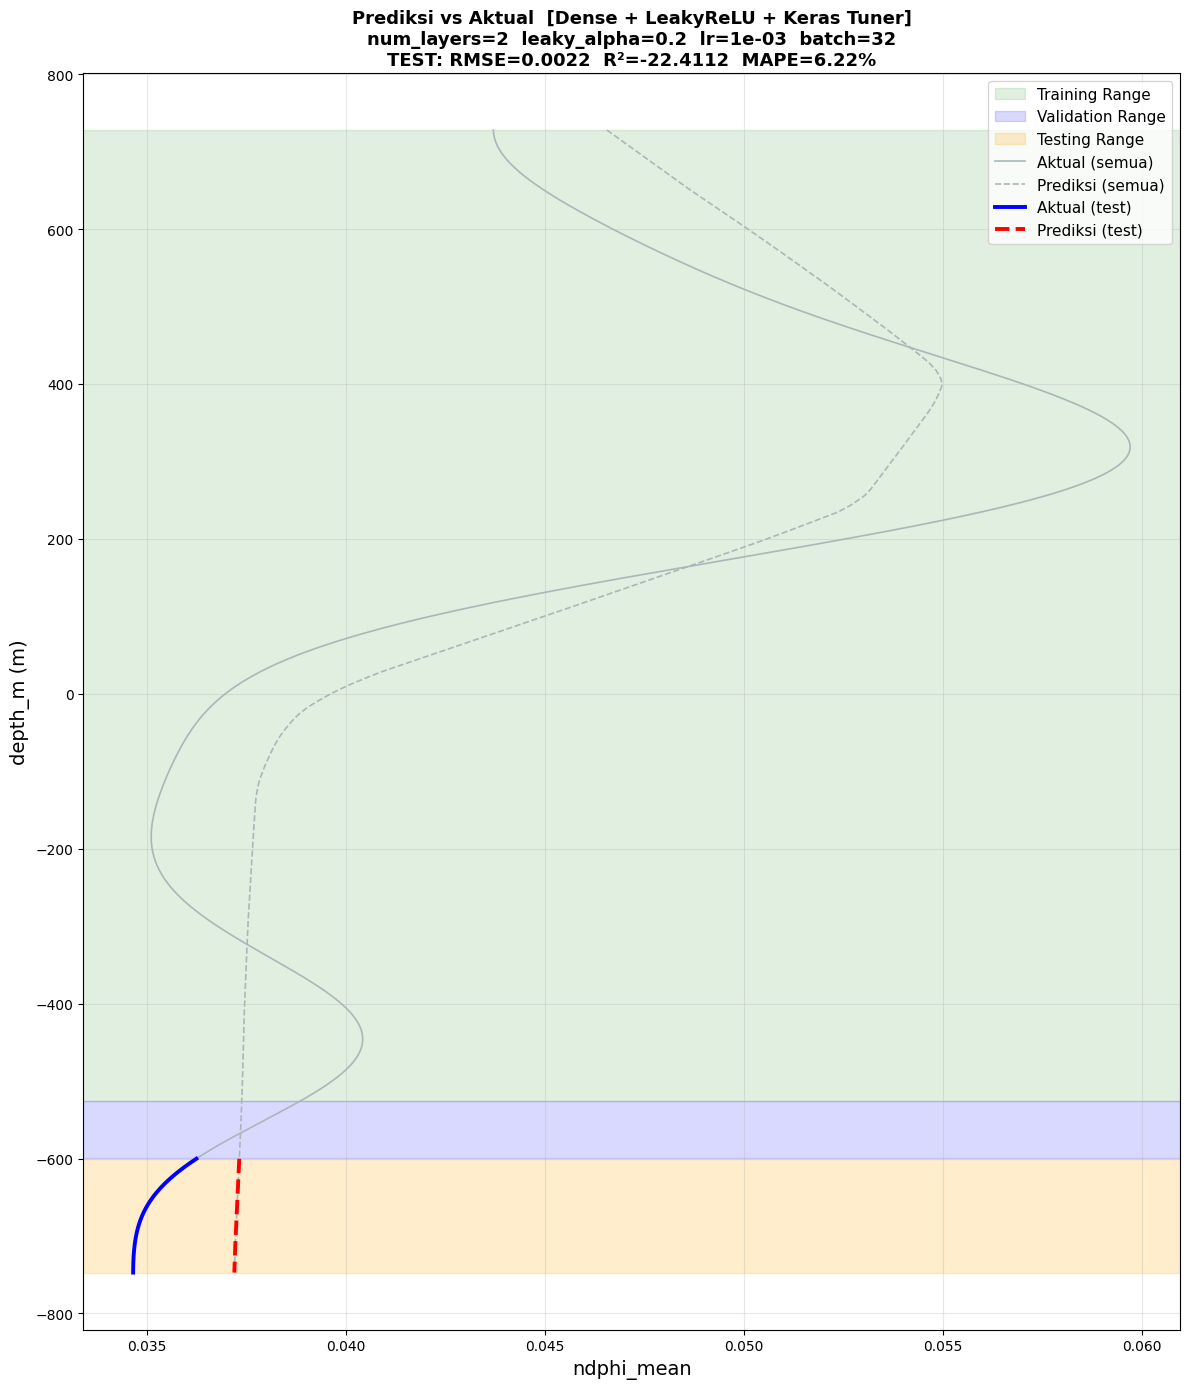

  Disimpan → dense_depth_profile.png



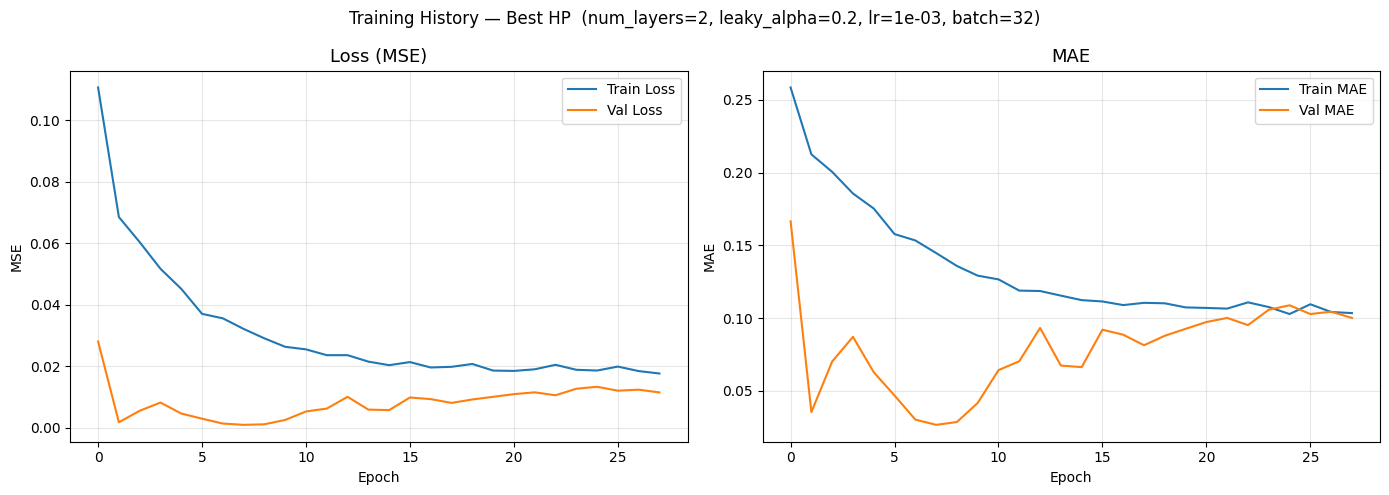

  Disimpan → dense_training_history.png



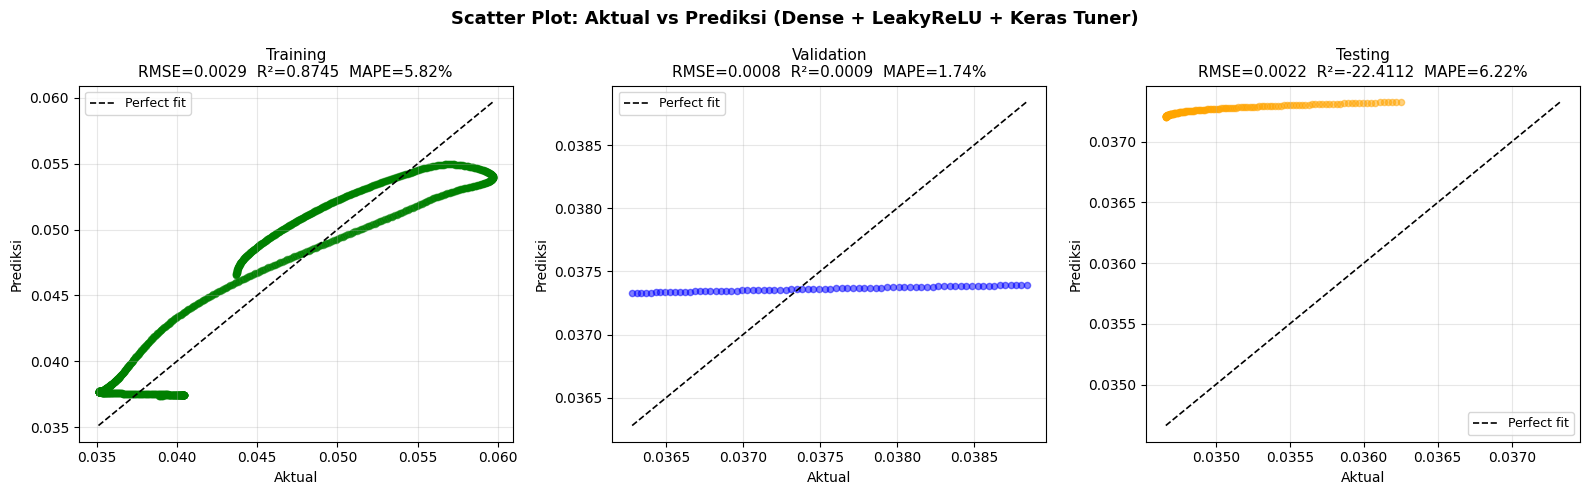

  Disimpan → dense_scatter.png


  TOP 5 TRIALS (Keras Tuner — Dense + LeakyReLU):
  #1  val_loss=0.034925
       num_layers=2  leaky_alpha=0.2  lr=1e-03  batch=32
       {'num_layers': 2, 'leaky_alpha': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'units_0': 64, 'dropout_0': 0.4, 'units_1': 128, 'dropout_1': 0.4, 'units_2': 16, 'dropout_2': 0.2}
  #2  val_loss=0.035349
       num_layers=3  leaky_alpha=0.3  lr=1e-03  batch=16
       {'num_layers': 3, 'leaky_alpha': 0.3, 'learning_rate': 0.001, 'batch_size': 16, 'units_0': 64, 'dropout_0': 0.0, 'units_1': 16, 'dropout_1': 0.0, 'units_2': 64, 'dropout_2': 0.30000000000000004}
  #3  val_loss=0.035449
       num_layers=1  leaky_alpha=0.3  lr=1e-03  batch=32
       {'num_layers': 1, 'leaky_alpha': 0.3, 'learning_rate': 0.001, 'batch_size': 32, 'units_0': 64, 'dropout_0': 0.4, 'units_1': 16, 'dropout_1': 0.4, 'units_2': 16, 'dropout_2': 0.0}
  #4  val_loss=0.035449
       num_layers=1  leaky_alpha=0.3  lr=1e-03  batch=32
       {'num_layer

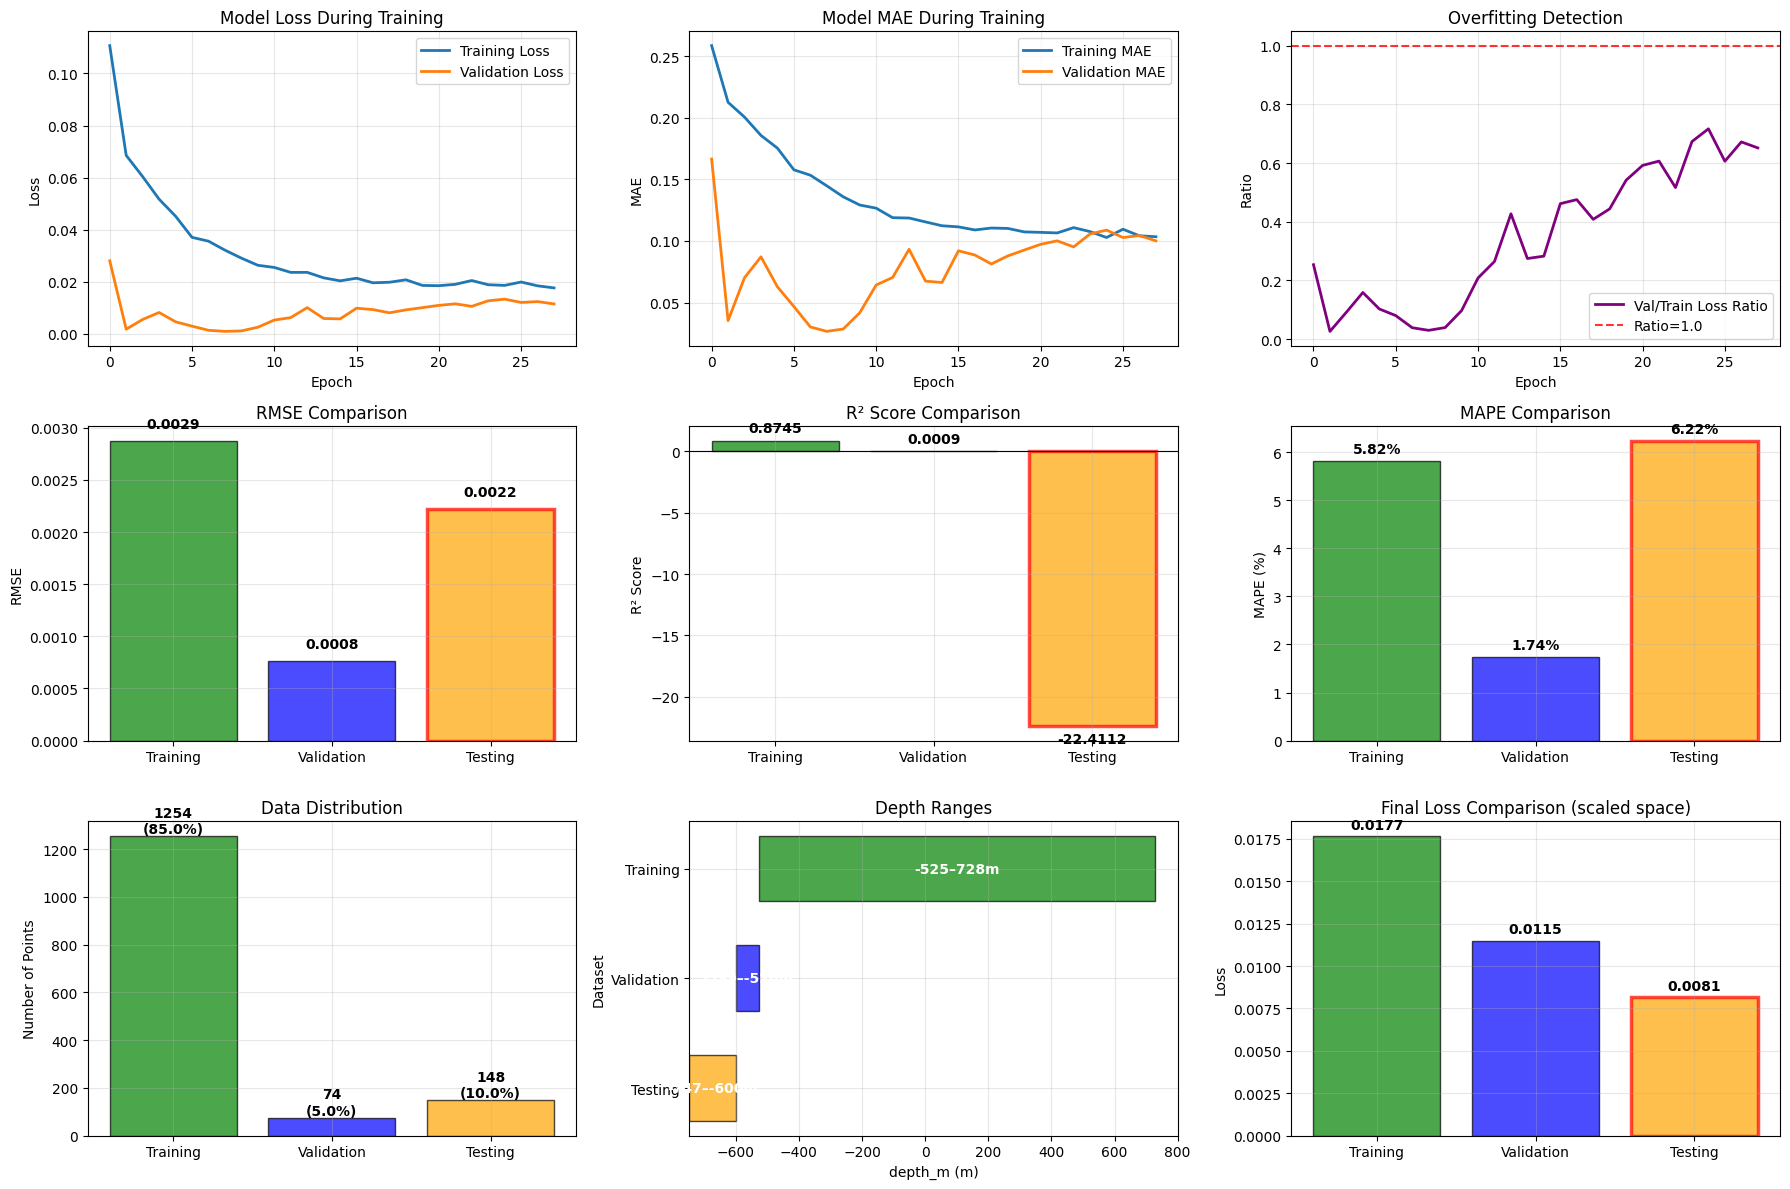

  Disimpan → dense_comprehensive_analysis.png



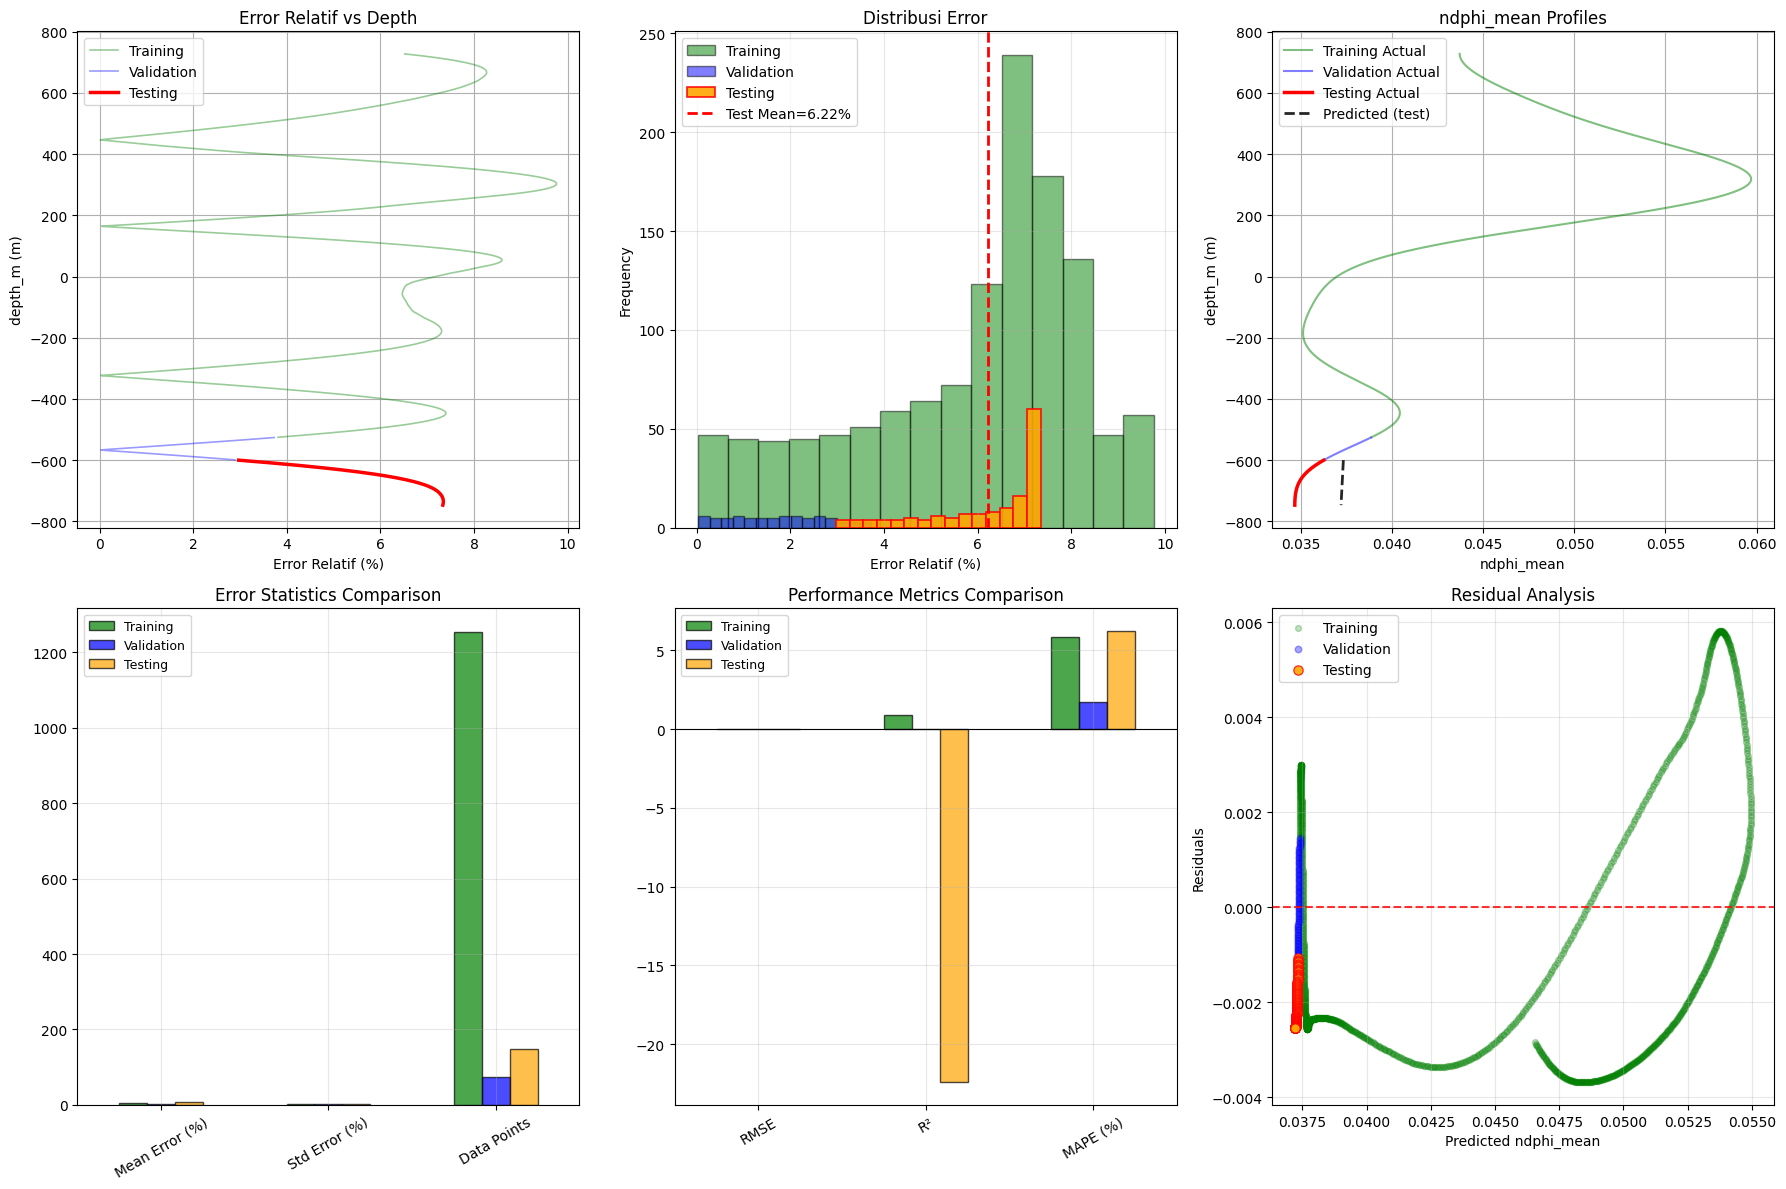

  Disimpan → dense_error_analysis.png



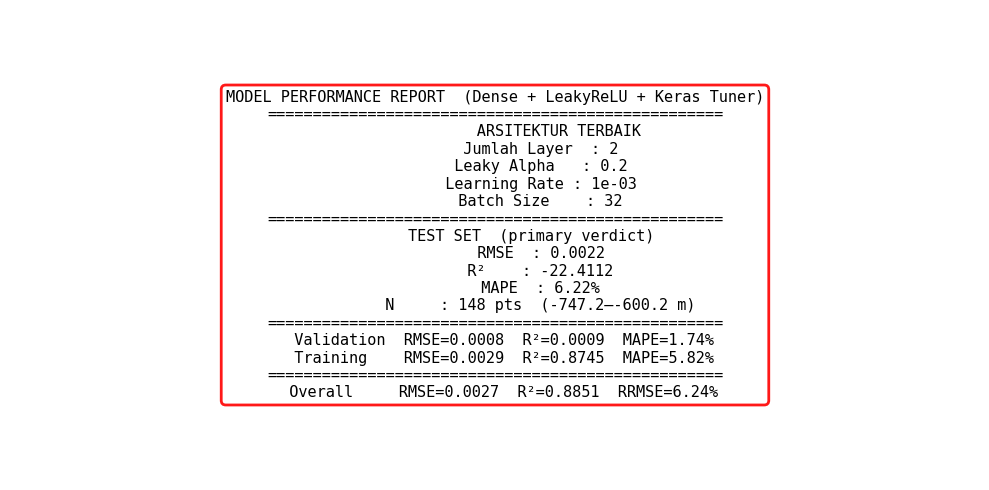

  Disimpan → dense_metrics_summary.png

  File disimpan → dense_predictions.csv

  Semua output berhasil dibuat!
    → dense_depth_profile.png
    → dense_training_history.png  (jika history tersedia)
    → dense_scatter.png
    → dense_comprehensive_analysis.png
    → dense_error_analysis.png
    → dense_metrics_summary.png
    → dense_predictions.csv



In [2]:
# =============================================================================
#  DENSE + LEAKYRELU + KERAS TUNER — Porosity Prediction (ndphi_mean)
#  Utah FORGE Site | Sumur FORGE 78B-32
#  Features : mt_res_ohmm + depth_m
#  Target   : ndphi_mean
#  Split    : depth-based  85 / 5 / 10  (train / val / test)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.initializers import GlorotUniform
import tensorflow as tf
import keras_tuner as kt
import math, os, random, joblib

# =============================================================================
# CONSTANTS
# =============================================================================
EPS      = 1e-10
DEPTH    = 'depth_m'
RES      = 'mt_res_ohmm'
PHI      = 'ndphi_mean'
PHI_PRED = 'ndphi_mean_pred'
ERR_COL  = 'Error_Relatif_Persen'
TYPE_COL = 'Data_Type'

# =============================================================================
# REPRODUCIBILITY
# =============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    print("Warning: deterministic ops not available on this device.")

# =============================================================================
# KERAS TUNER CONFIG
# =============================================================================
TUNER_DIR      = 'keras_tuner_results_dense'
TUNER_PROJECT  = 'dense_porosity'
MAX_TRIALS     = 200
TUNER_EPOCHS   = 50
TUNER_PATIENCE = 15
FINAL_EPOCHS   = 200
FINAL_PATIENCE = 20

# =============================================================================
# FILE PATHS
# =============================================================================
CSV_FILE      = 'resampled_1m_78B_AT90(ohm.m)_78.csv'
MODEL_FILE    = 'model_B_dense_tuned.keras'
SCALER_X_PATH = 'scaler_X_B_dense_tuned.pkl'
SCALER_Y_PATH = 'scaler_Y_B_dense_tuned.pkl'
BEST_HP_PATH  = 'best_hp_dense.pkl'
HISTORY_PATH  = 'training_history_dense.pkl'
force_retrain = True

# =============================================================================
# OUTPUT FILENAMES
# =============================================================================
OUT_DEPTH         = 'dense_depth_profile.png'
OUT_HISTORY       = 'dense_training_history.png'
OUT_SCATTER       = 'dense_scatter.png'
OUT_COMPREHENSIVE = 'dense_comprehensive_analysis.png'
OUT_ERROR         = 'dense_error_analysis.png'
OUT_SUMMARY       = 'dense_metrics_summary.png'
OUT_CSV           = 'dense_predictions.csv'

# =============================================================================
# SPLIT PERCENTAGES
# =============================================================================
TRAIN_PERC = 0.85
VAL_PERC   = 0.05
TEST_PERC  = 0.10

# =============================================================================
# 1) LOAD & SORT DATA
# =============================================================================
try:
    data = pd.read_csv(CSV_FILE, sep=';')
except FileNotFoundError:
    print("Error: File CSV tidak ditemukan!")
    exit()

print(f"Data berhasil dimuat: {len(data)} baris")

data_sorted = data.sort_values(DEPTH, ascending=False).reset_index(drop=True)
min_z   = data_sorted[DEPTH].min()
max_z   = data_sorted[DEPTH].max()
z_range = max_z - min_z

test_limit  = min_z + z_range * TEST_PERC
test_mask   = data_sorted[DEPTH] <= test_limit

test_data      = data_sorted[test_mask]
train_val_data = data_sorted[~test_mask]

train_val_range = train_val_data[DEPTH].max() - train_val_data[DEPTH].min()
train_limit     = train_val_data[DEPTH].max() - train_val_range * (
    TRAIN_PERC / (1 - TEST_PERC))

train_data      = train_val_data[train_val_data[DEPTH] >  train_limit]
validation_data = train_val_data[train_val_data[DEPTH] <= train_limit]

print(f"Range keseluruhan : {max_z:.2f}m – {min_z:.2f}m")
print(f"Training range    : {train_data[DEPTH].max():.2f}m – {train_data[DEPTH].min():.2f}m  ({len(train_data)} pts, {len(train_data)/len(data_sorted)*100:.1f}%)")
print(f"Validation range  : {validation_data[DEPTH].max():.2f}m – {validation_data[DEPTH].min():.2f}m  ({len(validation_data)} pts, {len(validation_data)/len(data_sorted)*100:.1f}%)")
print(f"Testing range     : {test_data[DEPTH].max():.2f}m – {test_data[DEPTH].min():.2f}m  ({len(test_data)} pts, {len(test_data)/len(data_sorted)*100:.1f}%)")

# =============================================================================
# 2) RAW FEATURE ARRAYS
# =============================================================================
X_train_raw = train_data[[RES, DEPTH]].values
y_train_raw = train_data[[PHI]].values
X_val_raw   = validation_data[[RES, DEPTH]].values
y_val_raw   = validation_data[[PHI]].values
X_test_raw  = test_data[[RES, DEPTH]].values
y_test_raw  = test_data[[PHI]].values

# =============================================================================
# 3) SCALERS (fit on train only)
# =============================================================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train_raw)
y_train_sc = scaler_y.fit_transform(y_train_raw)
X_val_sc   = scaler_X.transform(X_val_raw)
y_val_sc   = scaler_y.transform(y_val_raw)
X_test_sc  = scaler_X.transform(X_test_raw)
y_test_sc  = scaler_y.transform(y_test_raw)

# =============================================================================
# 4) LABEL DATA TYPE
# =============================================================================
def assign_data_type(z):
    if z <= test_limit:
        return 'Testing'
    elif z <= train_limit:
        return 'Validation'
    else:
        return 'Training'

data_sorted[TYPE_COL] = data_sorted[DEPTH].apply(assign_data_type)

# =============================================================================
# 5) HELPER: METRICS
# =============================================================================
def eval_metrics(y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPS))) * 100
    return rmse, r2, mape

# =============================================================================
# 6) MODEL BUILDER — tuning jumlah Dense+LeakyReLU layer {1, 2, 3}
# =============================================================================
def build_model(hp):
    num_layers  = hp.Int   ('num_layers',    min_value=1, max_value=3, step=1)
    leaky_alpha = hp.Choice('leaky_alpha',   values=[0.01, 0.1, 0.2, 0.3])
    lr          = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4, 5e-5, 1e-5])
    hp.Choice('batch_size', values=[4, 8, 16, 32])

    model = Sequential()

    for i in range(num_layers):
        units        = hp.Choice(f'units_{i}',   values=[16, 32, 64, 128])
        dropout_rate = hp.Float (f'dropout_{i}',
                                  min_value=0.0, max_value=0.4, step=0.1)

        if i == 0:
            model.add(Dense(
                units,
                input_dim=2,
                kernel_initializer=GlorotUniform(seed=SEED),
                name=f'dense_{i+1}'
            ))
        else:
            model.add(Dense(
                units,
                kernel_initializer=GlorotUniform(seed=SEED),
                name=f'dense_{i+1}'
            ))

        model.add(LeakyReLU(alpha=leaky_alpha, name=f'leaky_{i+1}'))
        model.add(Dropout(dropout_rate, seed=SEED, name=f'drop_{i+1}'))

    model.add(Dense(
        1,
        activation='linear',
        kernel_initializer=GlorotUniform(seed=SEED),
        name='output'
    ))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=MeanSquaredError(),
        metrics=['mae'],
    )
    return model

# =============================================================================
# 7) CUSTOM TUNER
# =============================================================================
class DenseTuner(kt.BayesianOptimization):

    def run_trial(self, trial, epochs=TUNER_EPOCHS, callbacks=None, **kwargs):
        hp         = trial.hyperparameters
        batch_size = hp.get('batch_size') if 'batch_size' in hp.values else 8

        model = self.hypermodel.build(hp)

        history = model.fit(
            X_train_sc, y_train_sc,
            validation_data=(X_val_sc, y_val_sc),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks or [],
            verbose=0,
        )

        # Penalize collapsed predictions
        val_preds = model.predict(X_val_sc, verbose=0).flatten()
        pred_std  = np.std(val_preds)
        true_std  = np.std(y_val_sc.flatten())
        std_ratio = pred_std / (true_std + 1e-8)
        penalty   = 0.05 * np.exp(-std_ratio)

        base_loss = min(history.history['val_loss'])
        score     = base_loss + penalty

        self.oracle.update_trial(trial.trial_id, {'val_loss': score})
        return history

# =============================================================================
# 8) RUN TUNER OR LOAD EXISTING MODEL
# =============================================================================
model_ready = (
    os.path.exists(MODEL_FILE)    and
    os.path.exists(SCALER_X_PATH) and
    os.path.exists(SCALER_Y_PATH) and
    os.path.exists(BEST_HP_PATH)  and
    not force_retrain
)

if model_ready:
    print("\nMemuat model & scaler yang sudah ada …")
    try:
        model    = load_model(MODEL_FILE)
        scaler_X = joblib.load(SCALER_X_PATH)
        scaler_y = joblib.load(SCALER_Y_PATH)
        best_hp  = joblib.load(BEST_HP_PATH)
        print(f"Model dimuat. Jumlah layer terbaik : {best_hp.get('num_layers')}")
    except Exception as e:
        print(f"Gagal memuat: {e}\nMelatih ulang …")
        force_retrain = True

if force_retrain:
    tuner = DenseTuner(
        hypermodel           = build_model,
        objective            = kt.Objective('val_loss', direction='min'),
        max_trials           = MAX_TRIALS,
        executions_per_trial = 1,
        seed                 = SEED,
        directory            = TUNER_DIR,
        project_name         = TUNER_PROJECT,
        overwrite            = True,
    )

    tuner.search_space_summary()

    search_callbacks = [
        EarlyStopping(monitor='val_loss', patience=TUNER_PATIENCE,
                      restore_best_weights=True),
    ]

    print("\n" + "="*60)
    print("  MULAI KERAS TUNER SEARCH (Dense + LeakyReLU) …")
    print(f"  Max trials : {MAX_TRIALS}  |  Epochs/trial : {TUNER_EPOCHS}")
    print("="*60 + "\n")

    tuner.search(
        epochs    = TUNER_EPOCHS,
        callbacks = search_callbacks,
    )

    best_hp_obj     = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_hp         = best_hp_obj.values
    best_batch      = best_hp.get('batch_size', 8)
    best_num_layers = best_hp.get('num_layers', 2)

    print("\n" + "="*60)
    print("  HYPERPARAMETER TERBAIK:")
    for k, v in best_hp.items():
        print(f"    {k:<25} = {v}")
    print("="*60 + "\n")

    model = tuner.hypermodel.build(best_hp_obj)
    model.summary()

    final_callbacks = [
        EarlyStopping(monitor='val_loss', patience=FINAL_PATIENCE,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=5, min_lr=1e-6),
    ]

    print("\nMelatih model final dengan HP terbaik …")
    history = model.fit(
        X_train_sc, y_train_sc,
        validation_data=(X_val_sc, y_val_sc),
        epochs=FINAL_EPOCHS,
        batch_size=best_batch,
        callbacks=final_callbacks,
        verbose=1,
    )

    # Simpan history untuk plotting
    joblib.dump(history.history, HISTORY_PATH)

    try:
        model.save(MODEL_FILE)
        joblib.dump(scaler_X, SCALER_X_PATH)
        joblib.dump(scaler_y, SCALER_Y_PATH)
        joblib.dump(best_hp,  BEST_HP_PATH)
        print(f"\nModel disimpan → {MODEL_FILE}")
    except Exception as e:
        print(f"Warning: tidak bisa menyimpan: {e}")

# =============================================================================
# 9) EVALUASI
# — Dense tidak pakai sequences, prediksi langsung row-wise
# =============================================================================
def predict_inverse(X_raw):
    return scaler_y.inverse_transform(
        model.predict(scaler_X.transform(X_raw), verbose=0)
    )

y_pred_train = predict_inverse(X_train_raw)
y_pred_val   = predict_inverse(X_val_raw)
y_pred_test  = predict_inverse(X_test_raw)

# Flatten untuk komputasi metrik
yt_train = y_train_raw.flatten()
yt_val   = y_val_raw.flatten()
yt_test  = y_test_raw.flatten()
yp_train = y_pred_train.flatten()
yp_val   = y_pred_val.flatten()
yp_test  = y_pred_test.flatten()

rmse_train, r2_train, mape_train = eval_metrics(yt_train, yp_train)
rmse_val,   r2_val,   mape_val   = eval_metrics(yt_val,   yp_val)
rmse_test,  r2_test,  mape_test  = eval_metrics(yt_test,  yp_test)

all_X_sc  = scaler_X.transform(data_sorted[[RES, DEPTH]].values)
all_y_pred = scaler_y.inverse_transform(
    model.predict(all_X_sc, verbose=0)).flatten()
y_true_all = data_sorted[PHI].values

rmse_overall, r2_overall, mape_overall = eval_metrics(y_true_all, all_y_pred)
rrmse_overall = np.sqrt(np.sum((y_true_all - all_y_pred)**2) /
                        (np.sum(y_true_all**2) + EPS)) * 100

data_sorted[PHI_PRED] = all_y_pred
data_sorted[ERR_COL]  = (
    np.abs(y_true_all - all_y_pred) /
    (np.abs(y_true_all) + EPS)
) * 100

train_sc     = data_sorted[data_sorted[TYPE_COL] == 'Training'].copy()
val_sc       = data_sorted[data_sorted[TYPE_COL] == 'Validation'].copy()
test_sc      = data_sorted[data_sorted[TYPE_COL] == 'Testing'].copy()
train_depths = train_sc[DEPTH]
val_depths   = val_sc[DEPTH]
test_depths  = test_sc[DEPTH]

train_d_min = train_data[DEPTH].min()
train_d_max = train_data[DEPTH].max()
val_d_min   = validation_data[DEPTH].min()
val_d_max   = validation_data[DEPTH].max()
test_d_min  = test_data[DEPTH].min()
test_d_max  = test_data[DEPTH].max()

# Residuals & relative errors (per row — tanpa offset window)
res_train = yt_train - yp_train
res_val   = yt_val   - yp_val
res_test  = yt_test  - yp_test

err_train = np.abs(res_train) / (np.abs(yt_train) + EPS) * 100
err_val   = np.abs(res_val)   / (np.abs(yt_val)   + EPS) * 100
err_test  = np.abs(res_test)  / (np.abs(yt_test)  + EPS) * 100

# Depth arrays — Dense tidak pakai offset (tidak ada window_size)
depth_train_arr = train_data[DEPTH].values
depth_val_arr   = validation_data[DEPTH].values
depth_test_arr  = test_data[DEPTH].values

# =============================================================================
# 10) PRINT HASIL
# =============================================================================
W_line = 80
print("\n" + "=" * W_line)
print(f"  EVALUASI MODEL DENSE + LEAKYRELU + KERAS TUNER")
print(f"  Best HP : num_layers={best_hp.get('num_layers')}"
      f"  leaky_alpha={best_hp.get('leaky_alpha')}"
      f"  lr={best_hp.get('learning_rate'):.0e}"
      f"  batch={best_hp.get('batch_size')}")
print("=" * W_line)
print(f"  {'Metrik':<22} {'Training':>12} {'Validation':>12} {'TEST':>12} {'Overall':>12}")
print("-" * W_line)
print(f"  {'RMSE':<22} {rmse_train:>12.4f} {rmse_val:>12.4f} {rmse_test:>12.4f} {rmse_overall:>12.4f}")
print(f"  {'R² Score':<22} {r2_train:>12.4f} {r2_val:>12.4f} {r2_test:>12.4f} {r2_overall:>12.4f}")
print(f"  {'MAPE (%)':<22} {mape_train:>12.2f} {mape_val:>12.2f} {mape_test:>12.2f} {mape_overall:>12.2f}")
print("-" * W_line)
print(f"  {'Data Points':<22} {len(train_sc):>12} {len(val_sc):>12} {len(test_sc):>12} {len(data_sorted):>12}")
print(f"  {'RRMSE Overall (%)':<22} {'':>12} {'':>12} {'':>12} {rrmse_overall:>12.2f}")
print("=" * W_line)
print(f"  >>> TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%  <<<")
print("=" * W_line)

# =============================================================================
# PLOT 1: DEPTH PROFILE  (section 10)
# =============================================================================
plt.figure(figsize=(12, 14))

if len(train_depths): plt.axhspan(train_depths.min(), train_depths.max(), alpha=0.12, color='green',  label='Training Range',   zorder=1)
if len(val_depths):   plt.axhspan(val_depths.min(),   val_depths.max(),   alpha=0.15, color='blue',   label='Validation Range', zorder=1)
if len(test_depths):  plt.axhspan(test_depths.min(),  test_depths.max(),  alpha=0.20, color='orange', label='Testing Range',    zorder=1)

plt.plot(data_sorted[PHI],      data_sorted[DEPTH], '-',  color='#aab7b8', lw=1.2, label='Aktual (semua)',   zorder=2)
plt.plot(data_sorted[PHI_PRED], data_sorted[DEPTH], '--', color='#aab7b8', lw=1.2, label='Prediksi (semua)', zorder=2)
plt.plot(test_sc[PHI],          test_sc[DEPTH],     '-',  color='blue',    lw=2.8, label='Aktual (test)',    zorder=4)
plt.plot(test_sc[PHI_PRED],     test_sc[DEPTH],     '--', color='red',     lw=2.8, label='Prediksi (test)',  zorder=4)

plt.xlabel(PHI, fontsize=14)
plt.ylabel(f'{DEPTH} (m)', fontsize=14)
plt.title(
    f'Prediksi vs Aktual  [Dense + LeakyReLU + Keras Tuner]\n'
    f'num_layers={best_hp.get("num_layers")}  '
    f'leaky_alpha={best_hp.get("leaky_alpha")}  '
    f'lr={best_hp.get("learning_rate"):.0e}  '
    f'batch={best_hp.get("batch_size")}\n'
    f'TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%',
    fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DEPTH, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_DEPTH}\n")

# =============================================================================
# PLOT 2: TRAINING HISTORY  (section 11)
# =============================================================================
if os.path.exists(HISTORY_PATH):
    hist = joblib.load(HISTORY_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist['loss'],     label='Train Loss')
    axes[0].plot(hist['val_loss'], label='Val Loss')
    axes[0].set_title('Loss (MSE)', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    mae_key  = 'mae'     if 'mae'     in hist else [k for k in hist if 'mae' in k and 'val' not in k][0]
    vmae_key = 'val_mae' if 'val_mae' in hist else [k for k in hist if 'val' in k and 'mae' in k][0]
    axes[1].plot(hist[mae_key],  label='Train MAE')
    axes[1].plot(hist[vmae_key], label='Val MAE')
    axes[1].set_title('MAE', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f'Training History — Best HP  '
        f'(num_layers={best_hp.get("num_layers")}, '
        f'leaky_alpha={best_hp.get("leaky_alpha")}, '
        f'lr={best_hp.get("learning_rate"):.0e}, '
        f'batch={best_hp.get("batch_size")})',
        fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_HISTORY, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  Disimpan → {OUT_HISTORY}\n")

# =============================================================================
# PLOT 3: SCATTER PLOT  (section 12)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits_plot = [
    ('Training',   yt_train, yp_train, 'green',  rmse_train, r2_train, mape_train),
    ('Validation', yt_val,   yp_val,   'blue',   rmse_val,   r2_val,   mape_val),
    ('Testing',    yt_test,  yp_test,  'orange', rmse_test,  r2_test,  mape_test),
]
for ax, (title, yt, yp, col, rmse, r2, mape) in zip(axes, splits_plot):
    ax.scatter(yt, yp, alpha=0.5, color=col, s=20)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
    ax.set_title(f'{title}\nRMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plot: Aktual vs Prediksi (Dense + LeakyReLU + Keras Tuner)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_SCATTER, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_SCATTER}\n")

# =============================================================================
# PLOT 4: TOP 5 TRIALS SUMMARY  (section 14)
# =============================================================================
if force_retrain:
    print("\n" + "="*60)
    print("  TOP 5 TRIALS (Keras Tuner — Dense + LeakyReLU):")
    print("="*60)
    try:
        best_trials = tuner.oracle.get_best_trials(num_trials=5)
        for rank, trial in enumerate(best_trials, 1):
            hp_vals = trial.hyperparameters.values
            score   = trial.score
            print(f"  #{rank}  val_loss={score:.6f}")
            print(f"       num_layers={hp_vals.get('num_layers')}  "
                  f"leaky_alpha={hp_vals.get('leaky_alpha')}  "
                  f"lr={hp_vals.get('learning_rate'):.0e}  "
                  f"batch={hp_vals.get('batch_size')}")
            print(f"       {hp_vals}")
    except Exception as e:
        print(f"  (Could not retrieve trial summary: {e})")
    print("="*60)

# =============================================================================
# PLOT 5: COMPREHENSIVE ANALYSIS (3×3)
# =============================================================================
datasets   = ['Training', 'Validation', 'Testing']
colors_bar = ['green', 'blue', 'orange']

plt.figure(figsize=(18, 12))

# ── Loss curve ───────────────────────────────────────────────────────────────
plt.subplot(3, 3, 1)
if os.path.exists(HISTORY_PATH):
    plt.plot(hist['loss'],     label='Training Loss',   linewidth=2)
    plt.plot(hist['val_loss'], label='Validation Loss', linewidth=2)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Model Loss During Training')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

# ── MAE curve ────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 2)
if os.path.exists(HISTORY_PATH):
    plt.plot(hist[mae_key],  label='Training MAE',   linewidth=2)
    plt.plot(hist[vmae_key], label='Validation MAE', linewidth=2)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Model MAE During Training')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.legend(); plt.grid(True, alpha=0.3)

# ── Overfitting detection ─────────────────────────────────────────────────────
plt.subplot(3, 3, 3)
if os.path.exists(HISTORY_PATH):
    tl = np.array(hist['loss'])
    vl = np.array(hist['val_loss'])
    plt.plot(vl / (tl + EPS), label='Val/Train Loss Ratio',
             linewidth=2, color='purple')
    plt.axhline(y=1.0, color='r', linestyle='--', label='Ratio=1.0', alpha=0.8)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Overfitting Detection')
plt.xlabel('Epoch'); plt.ylabel('Ratio')
plt.legend(); plt.grid(True, alpha=0.3)

# ── RMSE bar ──────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 4)
rmse_vals = [rmse_train, rmse_val, rmse_test]
bars = plt.bar(datasets, rmse_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('RMSE Comparison'); plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.0001,
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# ── R² bar ────────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 5)
r2_vals = [r2_train, r2_val, r2_test]
bars = plt.bar(datasets, r2_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('R² Score Comparison'); plt.ylabel('R² Score')
plt.axhline(0, color='black', lw=0.8)
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, r2_vals):
    offset = abs(max(r2_vals) - min(r2_vals)) * 0.02
    ypos   = v + offset if v >= 0 else v - offset
    va     = 'bottom'   if v >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width() / 2, ypos,
             f'{v:.4f}', ha='center', va=va, fontweight='bold')

# ── MAPE bar ──────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 6)
mape_vals = [mape_train, mape_val, mape_test]
bars = plt.bar(datasets, mape_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('MAPE Comparison'); plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, mape_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# ── Data distribution ─────────────────────────────────────────────────────────
plt.subplot(3, 3, 7)
data_counts = [len(train_sc), len(val_sc), len(test_sc)]
total_pts   = sum(data_counts)
bars = plt.bar(datasets, data_counts, color=colors_bar, alpha=0.7, edgecolor='black')
plt.title('Data Distribution'); plt.ylabel('Number of Points')
plt.grid(True, alpha=0.3)
for bar, cnt in zip(bars, data_counts):
    pct = cnt / (total_pts + EPS) * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{cnt}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

# ── Depth ranges ──────────────────────────────────────────────────────────────
plt.subplot(3, 3, 8)
depth_ranges = {
    'Training':   [train_d_min, train_d_max],
    'Validation': [val_d_min,   val_d_max],
    'Testing':    [test_d_min,  test_d_max],
}
for i, (name, (d_min, d_max)) in enumerate(depth_ranges.items()):
    if np.isfinite(d_min) and np.isfinite(d_max):
        plt.barh(i, d_max - d_min, left=d_min, height=0.6,
                 color=colors_bar[i], alpha=0.7, edgecolor='black')
        plt.text(d_min + (d_max - d_min) / 2, i,
                 f'{d_min:.0f}–{d_max:.0f}m',
                 ha='center', va='center', fontweight='bold', color='white')
plt.xlabel(f'{DEPTH} (m)'); plt.ylabel('Dataset')
plt.title('Depth Ranges')
plt.yticks(range(3), list(depth_ranges.keys()))
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()

# ── Final loss comparison (scaled space) ──────────────────────────────────────
plt.subplot(3, 3, 9)
if os.path.exists(HISTORY_PATH):
    final_train_loss = hist['loss'][-1]
    final_val_loss   = hist['val_loss'][-1]
else:
    final_train_loss = float('nan')
    final_val_loss   = float('nan')

# Test loss dalam scaled space — Dense langsung transform tanpa offset
yp_test_sc_final = model.predict(X_test_sc, verbose=0).flatten()
final_test_loss  = float(np.mean((y_test_sc.flatten() - yp_test_sc_final) ** 2))

loss_vals = [final_train_loss, final_val_loss, final_test_loss]
bars = plt.bar(datasets, loss_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('Final Loss Comparison (scaled space)')
plt.ylabel('Loss'); plt.grid(True, alpha=0.3)
for bar, v in zip(bars, loss_vals):
    if np.isfinite(v):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(x for x in loss_vals if np.isfinite(x)) * 0.015,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_COMPREHENSIVE, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_COMPREHENSIVE}\n")

# =============================================================================
# PLOT 6: ERROR ANALYSIS (2×3)
# — Dense: pakai data langsung dari data_sorted (tidak ada window offset)
# =============================================================================
plt.figure(figsize=(18, 12))

# ── Error Relatif vs Depth ────────────────────────────────────────────────────
plt.subplot(2, 3, 1)
plt.plot(err_train, depth_train_arr, 'g-', lw=1.2, label='Training',   alpha=0.4)
plt.plot(err_val,   depth_val_arr,   'b-', lw=1.2, label='Validation', alpha=0.4)
plt.plot(err_test,  depth_test_arr,  'r-', lw=2.5, label='Testing',    alpha=1.0)
plt.xlabel('Error Relatif (%)'); plt.ylabel(f'{DEPTH} (m)')
plt.title('Error Relatif vs Depth')
plt.legend(); plt.grid(True)

# ── Distribusi Error ──────────────────────────────────────────────────────────
plt.subplot(2, 3, 2)
plt.hist(err_train, bins=15, alpha=0.5, color='green',
         label='Training',   edgecolor='black')
plt.hist(err_val,   bins=15, alpha=0.5, color='blue',
         label='Validation', edgecolor='black')
plt.hist(err_test,  bins=15, alpha=0.9, color='orange',
         label='Testing',    edgecolor='red', linewidth=1.2)
plt.axvline(err_test.mean(), color='red', lw=2, linestyle='--',
            label=f'Test Mean={err_test.mean():.2f}%')
plt.xlabel('Error Relatif (%)'); plt.ylabel('Frequency')
plt.title('Distribusi Error')
plt.legend(); plt.grid(True, alpha=0.3)

# ── ndphi_mean Profiles ───────────────────────────────────────────────────────
plt.subplot(2, 3, 3)
plt.plot(yt_train, depth_train_arr, 'g-',  lw=1.5,
         label='Training Actual',   alpha=0.5)
plt.plot(yt_val,   depth_val_arr,   'b-',  lw=1.5,
         label='Validation Actual', alpha=0.5)
plt.plot(yt_test,  depth_test_arr,  'r-',  lw=2.5,
         label='Testing Actual',    alpha=1.0)
plt.plot(yp_test,  depth_test_arr,  'k--', lw=2.0,
         label='Predicted (test)',  alpha=0.85)
plt.xlabel(PHI); plt.ylabel(f'{DEPTH} (m)')
plt.title(f'{PHI} Profiles')
plt.legend(); plt.grid(True)

# ── Error Statistics Comparison ───────────────────────────────────────────────
plt.subplot(2, 3, 4)
stats_data = {
    'Training':   [err_train.mean(), err_train.std(), len(yt_train)],
    'Validation': [err_val.mean(),   err_val.std(),   len(yt_val)],
    'Testing':    [err_test.mean(),  err_test.std(),  len(yt_test)],
}
stats_df = pd.DataFrame(
    stats_data,
    index=['Mean Error (%)', 'Std Error (%)', 'Data Points'])
stats_df.plot(kind='bar', ax=plt.gca(),
              color=['green', 'blue', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Error Statistics Comparison')
plt.xticks(rotation=30); plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

# ── Performance Metrics Comparison ───────────────────────────────────────────
plt.subplot(2, 3, 5)
metrics_data = {
    'Training':   [rmse_train, r2_train, mape_train],
    'Validation': [rmse_val,   r2_val,   mape_val],
    'Testing':    [rmse_test,  r2_test,  mape_test],
}
metrics_df = pd.DataFrame(
    metrics_data,
    index=['RMSE', 'R²', 'MAPE (%)'])
metrics_df.plot(kind='bar', ax=plt.gca(),
                color=['green', 'blue', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Performance Metrics Comparison')
plt.xticks(rotation=30); plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.axhline(0, color='black', lw=0.8)

# ── Residual Analysis ─────────────────────────────────────────────────────────
plt.subplot(2, 3, 6)
plt.scatter(yp_train, res_train, alpha=0.25, color='green',
            label='Training',   s=18)
plt.scatter(yp_val,   res_val,   alpha=0.35, color='blue',
            label='Validation', s=22)
plt.scatter(yp_test,  res_test,  alpha=0.90, color='orange',
            label='Testing',    s=45,
            zorder=4, edgecolors='red', linewidths=0.8)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
plt.xlabel(f'Predicted {PHI}'); plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_ERROR, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_ERROR}\n")

# =============================================================================
# PLOT 7: SUMMARY BOX  (section 16)
# =============================================================================
plt.figure(figsize=(10, 5))
plt.axis('off')

textstr = (
    f"MODEL PERFORMANCE REPORT  (Dense + LeakyReLU + Keras Tuner)\n"
    f"{'='*50}\n"
    f"              ARSITEKTUR TERBAIK\n"
    f"          Jumlah Layer  : {best_hp.get('num_layers')}\n"
    f"          Leaky Alpha   : {best_hp.get('leaky_alpha')}\n"
    f"          Learning Rate : {best_hp.get('learning_rate'):.0e}\n"
    f"          Batch Size    : {best_hp.get('batch_size')}\n"
    f"{'='*50}\n"
    f"        TEST SET  (primary verdict)\n"
    f"          RMSE  : {rmse_test:.4f}\n"
    f"          R²    : {r2_test:.4f}\n"
    f"          MAPE  : {mape_test:.2f}%\n"
    f"          N     : {len(test_sc)} pts  ({test_d_min:.1f}–{test_d_max:.1f} m)\n"
    f"{'='*50}\n"
    f"  Validation  RMSE={rmse_val:.4f}  R²={r2_val:.4f}  MAPE={mape_val:.2f}%\n"
    f"  Training    RMSE={rmse_train:.4f}  R²={r2_train:.4f}  MAPE={mape_train:.2f}%\n"
    f"{'='*50}\n"
    f"  Overall     RMSE={rmse_overall:.4f}  R²={r2_overall:.4f}  RRMSE={rrmse_overall:.2f}%"
)

plt.text(0.5, 0.5, textstr, transform=plt.gca().transAxes,
         fontsize=11, va='center', ha='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white',
                   edgecolor='red', linewidth=2, alpha=0.9))
plt.tight_layout()
plt.savefig(OUT_SUMMARY, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_SUMMARY}\n")

# =============================================================================
# EXPORT CSV  (section 15)
# =============================================================================
results_frames = []
for label, df_split, X_raw, y_raw in [
    ('Training',   train_data,      X_train_raw, y_train_raw),
    ('Validation', validation_data, X_val_raw,   y_val_raw),
    ('Testing',    test_data,       X_test_raw,  y_test_raw),
]:
    y_pred_v = scaler_y.inverse_transform(
        model.predict(scaler_X.transform(X_raw), verbose=0)).flatten()
    y_true_v = y_raw.flatten()
    frame = pd.DataFrame({
        DEPTH    : df_split[DEPTH].values,
        PHI      : y_true_v,
        PHI_PRED : y_pred_v,
        ERR_COL  : np.where(
            np.abs(y_true_v) > EPS,
            np.abs((y_true_v - y_pred_v) / y_true_v) * 100,
            np.nan),
        TYPE_COL : label,
    })
    results_frames.append(frame)

results_df = pd.concat(results_frames, ignore_index=True)
results_df.to_csv(OUT_CSV, index=False)
print(f"  File disimpan → {OUT_CSV}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n  Semua output berhasil dibuat!")
print(f"    → {OUT_DEPTH}")
print(f"    → {OUT_HISTORY}  (jika history tersedia)")
print(f"    → {OUT_SCATTER}")
print(f"    → {OUT_COMPREHENSIVE}")
print(f"    → {OUT_ERROR}")
print(f"    → {OUT_SUMMARY}")
print(f"    → {OUT_CSV}\n")